# Cold Diffusion Models — Notebook 01: Understanding Cold Diffusion (Theory & Forward Process Visualization)

Cold Diffusion generalizes the standard Denoising Diffusion Probabilistic Models (DDPM) framework by showing that **diffusion models do not require Gaussian noise** to work. Instead, any differentiable and deterministic image degradation (such as blurring, downsampling, masking, desaturation, or morphing) can define a valid forward process, and a neural network can be trained to invert it step-by-step.

### Objectives of this Notebook
1. Compare the mathematical framework of Hot (Gaussian) vs. Cold (Deterministic) Diffusion.
2. Visualize the progressive degradation trajectories for all 6 degradation types supported in this repository.
3. Understand and plot the different degradation schedules (Constant, Incremental, Exponential).
4. Walk through a 1D simulation comparing **Algorithm 1** (Direct Reconstruction) vs. **Algorithm 2** (Step-Down / Residual Correction).
5. Understand the **Symmetry-Breaking Problem** in unconditional generation.

## Table of Contents
1. Hot vs. Cold Diffusion: Mathematical Foundations
2. Environment Setup & Submodule Path Insertion
3. Loading Sample Images
4. Visualization of Forward Degradation Trajectories
   - 4.1 Gaussian Blur
   - 4.2 Gaussian Mask (Inpainting)
   - 4.3 Resolution Downsampling
   - 4.4 Snowification
   - 4.5 Color Desaturation
   - 4.6 Animorphosis (Image Morphing)
5. Degradation Schedules Visualized
6. Reconstruction Algorithms: Algorithm 1 vs. Algorithm 2 (1D Toy Simulation)
7. Unconditional Generation & The Symmetry-Breaking Challenge

## 1. Hot vs. Cold Diffusion: Mathematical Foundations

In standard **Hot Diffusion (DDPM)**, the forward process progressively adds Gaussian noise to an image $x_0$:
$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t}x_0, (1 - \bar{\alpha}_t)\mathbf{I})$$
As $t \to T$, the image converges to isotropic Gaussian noise.

In **Cold Diffusion**, the forward process is defined by an arbitrary, deterministic degradation function $D(x_0, t)$:
$$x_t = D(x_0, t)$$
Here, $D(x_0, 0) = x_0$, and $D(x_0, T)$ is the fully degraded state (e.g., completely blurred image, fully masked image, or grayscale image).

The training objective is to train a neural network $R_\theta(x_t, t)$ to predict the clean image $x_0$ directly:
$$\min_\theta \mathbb{E}_{x_0, t} \| R_\theta(x_t, t) - x_0 \|_1$$
Once we have an estimator $\hat{x}_0 = R_\theta(x_t, t)$, we reconstruct the image by stepping down from $t$ to $t-1$ using restoration algorithms.

## 2. Environment Setup & Submodule Path Insertion

In [12]:
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# ── Paths Configuration ────────────────────────────────────────────────────────
REPO_ROOT = Path('/workspace')
DATA_ROOT = REPO_ROOT / 'data'
RESULTS_DIR = REPO_ROOT / 'results' / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Add all subdirectories to sys.path for direct importing
submodules = [
    'deblurring-diffusion-pytorch',
    'defading-diffusion-pytorch',
    'resolution-diffusion-pytorch',
    'denoising-diffusion-pytorch',
    'demixing-diffusion-pytorch',
    'defading-generation-diffusion-pytorch',
    'snowification',
    'decolor-diffusion'
]
for m in submodules:
    sys.path.insert(0, str(REPO_ROOT / m))

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print("Submodule paths registered successfully.")

Device: cuda
Submodule paths registered successfully.


## 3. Loading Sample Images

Loaded CelebA sample image: 0.png


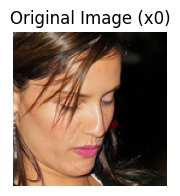

In [13]:
to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1)  # Scale to [-1, 1]
])

to_display = lambda t: t.detach().cpu().clamp(-1, 1).add(1).div(2).permute(1, 2, 0).numpy()

# Try loading a sample human face (CelebA) image as starting point (x0)
celeba_path = DATA_ROOT / 'root_celebA_128_train_new'
sample_img = None

if celeba_path.exists() and any(celeba_path.glob('*.png')):
    img_file = next(celeba_path.glob('*.png'))
    sample_img = to_tensor(Image.open(img_file).convert('RGB')).to(DEVICE)
    print(f"Loaded CelebA sample image: {img_file.name}")
else:
    # Fallback to a synthetic face-like template image if dataset isn't prepared yet
    print("CelebA sample not found. Generating a synthetic face template...")
    grid = torch.ones((3, 128, 128)) * 0.95
    # draw a simple human face structure (skin color background, black eyes)
    for y in range(128):
        for x in range(128):
            if (x-64)**2 + (y-64)**2 < 1920:
                grid[:, y, x] = torch.tensor([0.95, 0.8, 0.7])  # skin color
            if ((x-48)**2 + (y-48)**2 < 48) or ((x-80)**2 + (y-48)**2 < 48):
                grid[:, y, x] = torch.tensor([0.1, 0.1, 0.1])  # eyes
            if (x-64)**2 + (y-80)**2 < 32:
                grid[:, y, x] = torch.tensor([0.8, 0.3, 0.3])  # mouth
    sample_img = to_tensor(transforms.ToPILImage()(grid)).to(DEVICE)

plt.figure(figsize=(2, 2))
plt.imshow(to_display(sample_img))
plt.title("Original Image (x0)")
plt.axis('off')
plt.show()

## 4. Visualization of Forward Degradation Trajectories

### 4.1 Gaussian Blur

Applying sequential Gaussian blur operations to the image. 

The kernel std dev increases linearly or exponentially at each step.

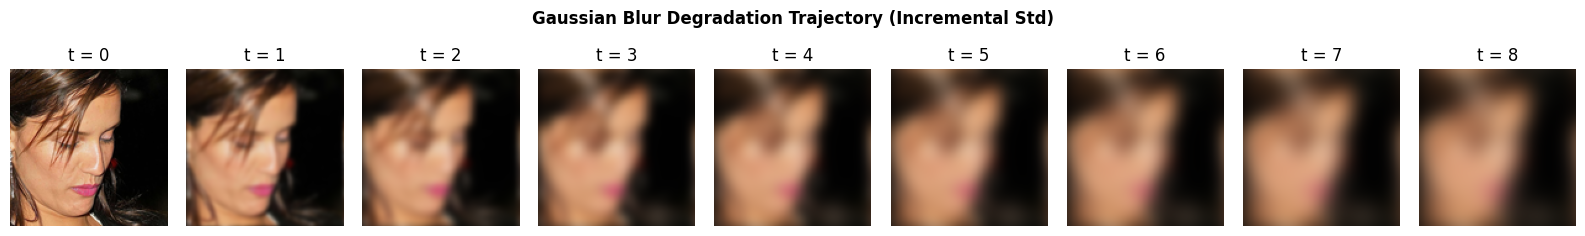

In [14]:
import torchgeometry as tgm

def apply_gaussian_blur(img, num_steps=8, kernel_std=2.0, routine='Incremental'):
    x = img.unsqueeze(0)
    channels = x.shape[1]
    sequence = [img.clone().cpu()]
    
    accumulated = x.clone()
    for step in range(num_steps):
        if routine == 'Constant':
            std = kernel_std
        elif routine == 'Incremental':
            std = kernel_std * (step + 1)
            
        kernel = tgm.image.get_gaussian_kernel2d((11, 11), (std, std))
        k = kernel.unsqueeze(0).unsqueeze(0).repeat(channels, 1, 1, 1).to(DEVICE)
        padded = F.pad(accumulated, [5, 5, 5, 5], mode='circular')
        accumulated = F.conv2d(padded, k, groups=channels)
        sequence.append(accumulated.squeeze(0).cpu())
    return sequence

blur_seq = apply_gaussian_blur(sample_img, num_steps=8, kernel_std=1.5, routine='Incremental')

fig, axes = plt.subplots(1, 9, figsize=(16, 2.2))
for t, ax in enumerate(axes):
    ax.imshow(to_display(blur_seq[t]))
    ax.set_title(f"t = {t}")
    ax.axis('off')
plt.suptitle("Gaussian Blur Degradation Trajectory (Incremental Std)", fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'blur_trajectory.png'), dpi=120, bbox_inches='tight')
plt.show()

### 4.2 Gaussian Mask (Inpainting)

Progressively masks the center of the image using a Gaussian fade mask.

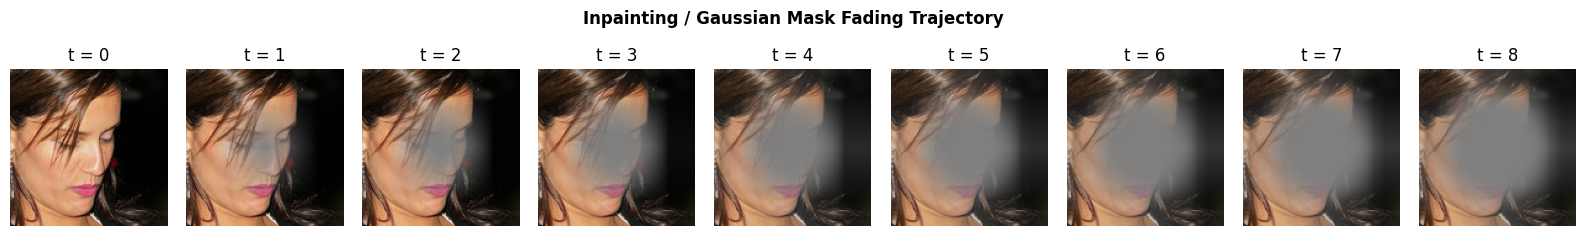

In [15]:
def apply_gaussian_mask(img, num_steps=8, kernel_std=0.2, initial_mask=1):
    x = img.unsqueeze(0)
    sequence = [img.clone().cpu()]
    
    curr = x.clone()
    for step in range(num_steps):
        std = kernel_std * (step + initial_mask)
        ksize = int(std * 6) | 1
        ksize = max(ksize, 3)
        kernel = tgm.image.get_gaussian_kernel2d((ksize, ksize), (std, std))
        fade_kernel = 1.0 - kernel / kernel.max()
        fade_kernel = fade_kernel.unsqueeze(0).unsqueeze(0)
        
        mask = F.interpolate(fade_kernel, size=(x.shape[2], x.shape[3]), mode='bilinear', align_corners=False)
        mask = mask.expand_as(curr).to(DEVICE)
        curr = curr * mask
        sequence.append(curr.squeeze(0).cpu())
    return sequence

mask_seq = apply_gaussian_mask(sample_img, num_steps=8, kernel_std=0.15)

fig, axes = plt.subplots(1, 9, figsize=(16, 2.2))
for t, ax in enumerate(axes):
    ax.imshow(to_display(mask_seq[t]))
    ax.set_title(f"t = {t}")
    ax.axis('off')
plt.suptitle("Inpainting / Gaussian Mask Fading Trajectory", fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'mask_trajectory.png'), dpi=120, bbox_inches='tight')
plt.show()

### 4.3 Resolution Downsampling

Progressively reduces the image resolution (downsampling) and then upsamples it back using bicubic interpolation. 
At step $t$, the effective resolution of the image is halved.

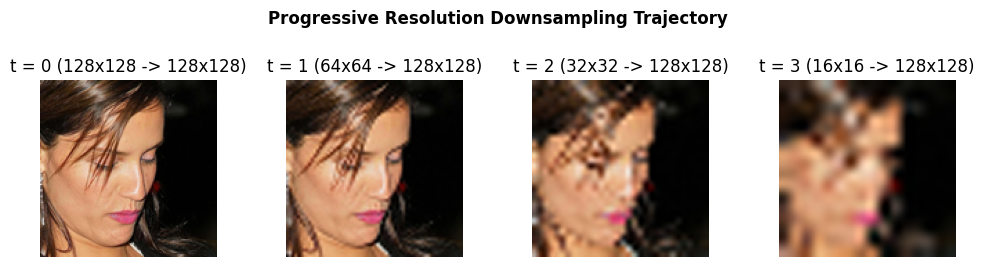

In [16]:
def apply_resolution_downsampling(img, num_steps=3):
    x = img.unsqueeze(0)
    sequence = [img.clone().cpu()]
    
    for step in range(num_steps):
        image_size = x.shape[2]
        # Incremental factor 2 routine
        dec_size = int(image_size - image_size / (2 ** (step + 1)))
        target_size = max(image_size - dec_size, 1)
        
        x_down = F.interpolate(x, size=target_size, mode='bicubic', align_corners=False)
        x_up = F.interpolate(x_down, size=image_size, mode='bicubic', align_corners=False)
        sequence.append(x_up.squeeze(0).cpu())
    return sequence

res_seq = apply_resolution_downsampling(sample_img, num_steps=3)

image_size = sample_img.shape[1]

fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
for t, ax in enumerate(axes):
    ax.imshow(to_display(res_seq[t]))
    res = image_size // (2**t)
    ax.set_title(f"t = {t} ({res}x{res} -> {image_size}x{image_size})")
    ax.axis('off')
plt.suptitle("Progressive Resolution Downsampling Trajectory", fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'resolution_trajectory.png'), dpi=120, bbox_inches='tight')
plt.show()

### 4.4 Snowification

Applies progressive snow accumulation. We try importing the repository's `Snow` implementation. If running outside the fully built docker workspace environment, we fallback to a simulated visual representation.

Failed to import repository Snow module: unsupported operand type(s) for +: 'NoneType' and 'float'. Running fallback simulation...


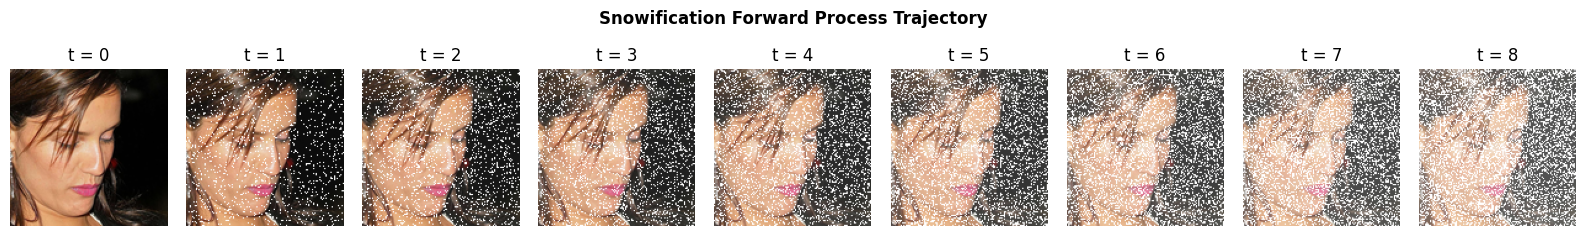

In [17]:
try:
    from diffusion.forward_process_impl import Snow
    # Instantiate repository snow process
    snow_proc = Snow(image_size=(sample_img.shape[1], sample_img.shape[2]), snow_level=3, num_timesteps=8, batch_size=1)
    snow_seq = [sample_img.cpu()]
    curr = sample_img.unsqueeze(0).to(DEVICE)
    for i in range(8):
        curr = snow_proc.forward(curr, i)
        snow_seq.append(curr.squeeze(0).cpu())
    print("Using official repository Snow module.")
except Exception as e:
    print(f"Failed to import repository Snow module: {e}. Running fallback simulation...")
    # Simulated snowification
    def apply_snow_simulation(img, num_steps=8):
        x = img.clone().cpu()
        sequence = [x]
        h, w = x.shape[1], x.shape[2]
        for step in range(1, num_steps + 1):
            snowy = x.clone()
            # Random white spots
            mask = torch.rand(1, h, w) > (0.96 - 0.04 * step)
            snowy[mask.repeat(3, 1, 1)] = 1.0
            # Wash out brightness slightly
            snowy = snowy * (1.0 - 0.04 * step) + 0.04 * step
            sequence.append(snowy)
        return sequence
    snow_seq = apply_snow_simulation(sample_img, num_steps=8)

fig, axes = plt.subplots(1, 9, figsize=(16, 2.2))
for t, ax in enumerate(axes):
    ax.imshow(to_display(snow_seq[t]))
    ax.set_title(f"t = {t}")
    ax.axis('off')
plt.suptitle("Snowification Forward Process Trajectory", fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'snow_trajectory.png'), dpi=120, bbox_inches='tight')
plt.show()

### 4.5 Color Desaturation

Progressively converts a color image into a grayscale image by mixing the RGB channels.

Using official repository DeColorization module.


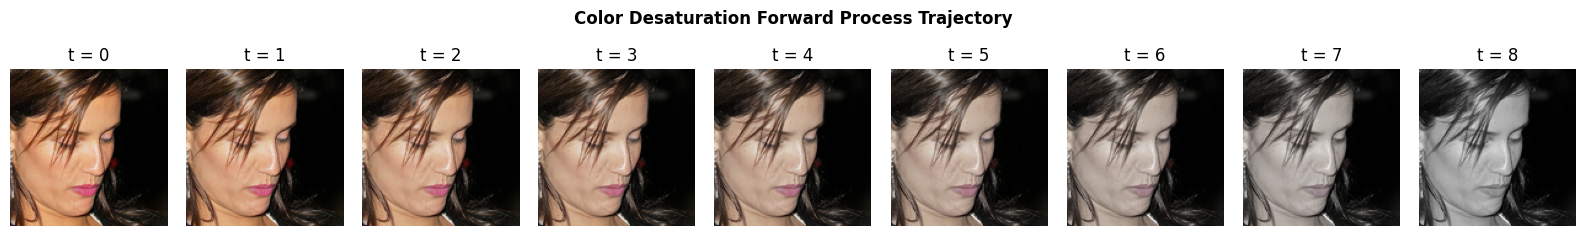

In [18]:
try:
    from diffusion.forward_process_impl import DeColorization
    decolor_proc = DeColorization(decolor_routine='Linear', num_timesteps=8, channels=3)
    decolor_seq = [sample_img.cpu()]
    curr = sample_img.unsqueeze(0).to(DEVICE)
    for i in range(8):
        curr = decolor_proc.forward(curr, i)
        decolor_seq.append(curr.squeeze(0).cpu())
    print("Using official repository DeColorization module.")
except Exception as e:
    print(f"Failed to import repository DeColorization: {e}. Running fallback simulation...")
    def apply_decolor_simulation(img, num_steps=8):
        gray = 0.2989 * img[0] + 0.5870 * img[1] + 0.1140 * img[2]
        gray = gray.unsqueeze(0).repeat(3, 1, 1)
        sequence = []
        for step in range(num_steps + 1):
            alpha = 1.0 - (step / num_steps)
            sequence.append((alpha * img + (1.0 - alpha) * gray).cpu())
        return sequence
    decolor_seq = apply_decolor_simulation(sample_img, num_steps=8)

fig, axes = plt.subplots(1, 9, figsize=(16, 2.2))
for t, ax in enumerate(axes):
    ax.imshow(to_display(decolor_seq[t]))
    ax.set_title(f"t = {t}")
    ax.axis('off')
plt.suptitle("Color Desaturation Forward Process Trajectory", fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'decolor_trajectory.png'), dpi=120, bbox_inches='tight')
plt.show()

### 4.6 Animorphosis (Image Morphing)

The forward process is a linear interpolation between two manifolds (e.g. morphing a human face into an animal face). 

At $t=0$, we have a human face. As $t$ increases, we gradually morph it into a real animal face loaded from the AFHQ dataset.

Loaded AFHQ animal face (cat) for morphing: flickr_cat_000002.jpg


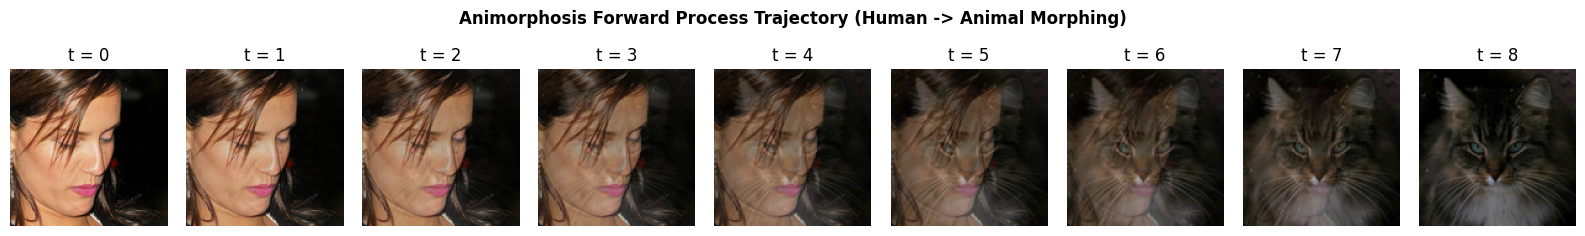

In [19]:
# Try loading a real animal face from AFHQ dataset
afhq_path = DATA_ROOT / 'AFHQ' / 'afhq' / 'train'
target_img = None

if afhq_path.exists():
    for category in ['cat', 'dog', 'wild']:
        cat_dir = afhq_path / category
        if cat_dir.exists() and any(cat_dir.glob('*.*')):
            img_file = next(cat_dir.glob('*.*'))
            # Load, convert to RGB, and resize to match the sample face dimension
            h, w = sample_img.shape[1], sample_img.shape[2]
            raw_img = Image.open(img_file).convert('RGB').resize((w, h))
            target_img = to_tensor(raw_img).to(DEVICE)
            print(f"Loaded AFHQ animal face ({category}) for morphing: {img_file.name}")
            break

if target_img is None:
    print("AFHQ animal face not found. Generating a synthetic cartoon animal face template...")
    # Create a simple brown cartoon animal face representation
    h, w = sample_img.shape[1], sample_img.shape[2]
    grid_target = torch.ones((3, h, w)) * 0.9
    for y in range(h):
        for x in range(w):
            xf, yf = x * 32.0 / w, y * 32.0 / h
            # ears
            if ((xf-8)**2 + (yf-8)**2 < 16) or ((xf-24)**2 + (yf-8)**2 < 16):
                grid_target[:, y, x] = torch.tensor([0.5, 0.3, 0.15])  # dark brown
            # face head
            if (xf-16)**2 + (yf-18)**2 < 120:
                grid_target[:, y, x] = torch.tensor([0.65, 0.45, 0.25])  # brown
            # snout area
            if (xf-16)**2 + (yf-22)**2 < 20:
                grid_target[:, y, x] = torch.tensor([0.85, 0.75, 0.6])  # light snout
            # nose
            if (xf-16)**2 + (yf-20)**2 < 2:
                grid_target[:, y, x] = torch.tensor([0.1, 0.1, 0.1])  # black nose
            # eyes
            if ((xf-12)**2 + (yf-14)**2 < 2) or ((xf-20)**2 + (yf-14)**2 < 2):
                grid_target[:, y, x] = torch.tensor([0.1, 0.1, 0.1])  # black eyes
    target_img = to_tensor(transforms.ToPILImage()(grid_target)).to(DEVICE)

def apply_animorphosis(x0, y0, num_steps=8):
    sequence = []
    for step in range(num_steps + 1):
        alpha = step / num_steps
        sequence.append(((1.0 - alpha) * x0 + alpha * y0).cpu())
    return sequence

morph_seq = apply_animorphosis(sample_img, target_img, num_steps=8)

fig, axes = plt.subplots(1, 9, figsize=(16, 2.2))
for t, ax in enumerate(axes):
    ax.imshow(to_display(morph_seq[t]))
    ax.set_title(f"t = {t}")
    ax.axis('off')
plt.suptitle("Animorphosis Forward Process Trajectory (Human -> Animal Morphing)", fontsize=12, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'animorphosis_trajectory.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Degradation Schedules Visualized

Schedules define how the severity (e.g. Std Dev $\sigma$ of Gaussian Blur) progresses over the timesteps $t$. Below, we plot Constant, Incremental, and Exponential schedules.

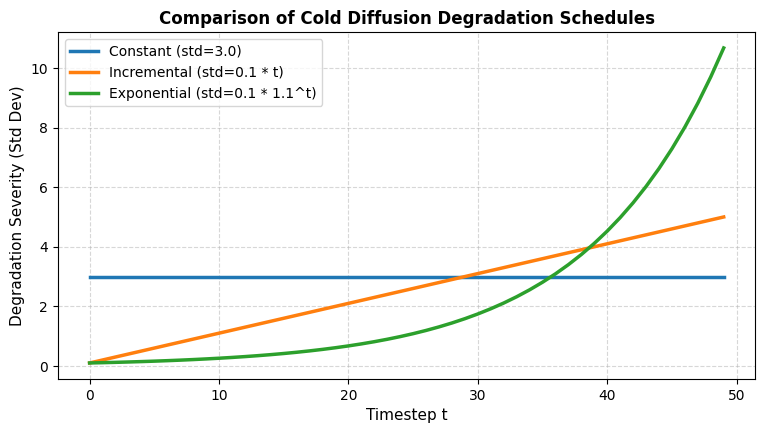

In [20]:
timesteps = np.arange(50)
constant_std = np.full_like(timesteps, 3.0, dtype=float)
incremental_std = 0.1 * (timesteps + 1)
exponential_std = 0.1 * (1.1 ** timesteps)

plt.figure(figsize=(9, 4.5))
plt.plot(timesteps, constant_std, label='Constant (std=3.0)', linewidth=2.5)
plt.plot(timesteps, incremental_std, label='Incremental (std=0.1 * t)', linewidth=2.5)
plt.plot(timesteps, exponential_std, label='Exponential (std=0.1 * 1.1^t)', linewidth=2.5)
plt.xlabel('Timestep t', fontsize=11)
plt.ylabel('Degradation Severity (Std Dev)', fontsize=11)
plt.title('Comparison of Cold Diffusion Degradation Schedules', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(str(RESULTS_DIR / 'degradation_schedules.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Reconstruction Algorithms: Algorithm 1 vs. Algorithm 2

Once we have a trained neural network $R_\theta(x_t, t) = \hat{x}_0$, how do we sample/restore step-by-step?

### 6.1 1D Toy Simulation

### Algorithm 1: Naive Direct Reconstruction
Reconstructs the image at $t-1$ by applying the forward degradation process directly to the predicted $\hat{x}_0$:
$$x_{t-1} = D(R_\theta(x_t, t), t-1)$$
*Crucial Limitation*: If the model makes a prediction error, this error propagates and accumulates directly across steps because the reconstruction $x_{t-1}$ is determined *solely* by the model's current estimate $\hat{x}_0$, completely discarding the actual observed state $x_t$.

### Algorithm 2: Residual Correction ($x_0$ step-down, Equation 8 in the paper)
Anchors the prediction to the observed state $x_t$ by adding the residual error between $x_t$ and the degraded prediction $D(\hat{x}_0, t)$:
$$x_{t-1} = x_t - D(R_\theta(x_t, t), t) + D(R_\theta(x_t, t), t-1)$$
This is equivalent to:
$$x_{t-1} = D(\hat{x}_0, t-1) + \underbrace{[x_t - D(\hat{x}_0, t)]}_{\text{Residual Correction}}$$
The term in brackets acts as a correction factor that offsets errors introduced by the model's imperfect prediction of $x_0$.

---

### Why a Simple Constant Bias Hides the Difference
In a simple simulation where the model makes a constant prediction error (e.g., $R_\theta(x_t, t) = x_0 + \epsilon$), the residual correction in Algorithm 2 evaluates to:
$$x_{t-1} = x_t - D(x_0 + \epsilon, t) + D(x_0 + \epsilon, t-1)$$
For a linear operator $D$, this evaluates to:
$$x_{t-1} = x_t - D(x_0, t) - D(\epsilon, t) + D(x_0, t-1) + D(\epsilon, t-1)$$
Since $x_t = D(x_0, t)$ by definition, this simplifies exactly to:
$$x_{t-1} = D(x_0 + \epsilon, t-1) = D(R_\theta(x_t, t), t-1)$$
This is *identical* to Algorithm 1! As a result, when the model's prediction does not depend on the input state $x_t$, both algorithms produce identical trajectories, and their curves overlap completely on a graph.

### The Real Case: Input-Dependent Imperfect Model
In reality, the model's predictions depend on the degraded state $x_t$ (which carries compounding errors under Algorithm 1). Let's simulate an imperfect model where the prediction is a function of the input $x_t$, showing the true divergence of both algorithms.

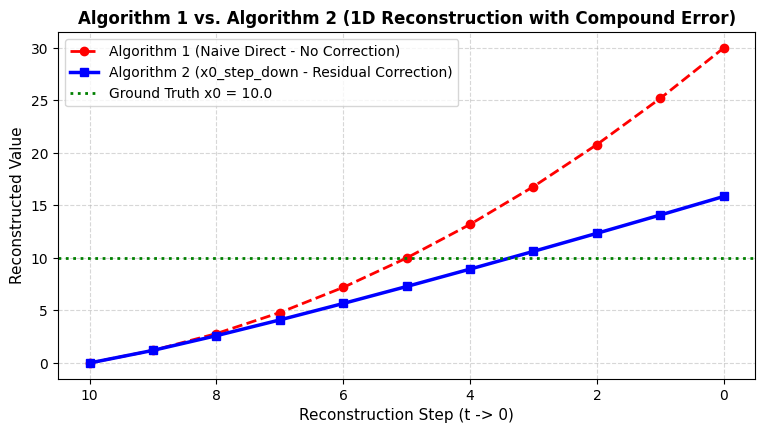

In [21]:
T = 10
x_0 = 10.0

# D(x, t) - Linear decay degradation operator
def D(x, t):
    return x * (1.0 - t / T)

# Imperfect model that estimates x_0 based on x_t, but has a constant bias of +2.0
def R_theta(x_t, t):
    if t == T:
        return x_0 + 2.0
    c_t = 1.0 - t / T
    return x_t / c_t + 2.0

# --- Algorithm 1 Reconstruction ---
def alg1_reconstruct():
    x = D(x_0, T)
    path = [x]
    for t in range(T, 0, -1):
        x0_hat = R_theta(x, t)
        x = D(x0_hat, t - 1)
        path.append(x)
    return path

# --- Algorithm 2 Reconstruction ---
def alg2_reconstruct():
    x = D(x_0, T)
    path = [x]
    for t in range(T, 0, -1):
        x0_hat = R_theta(x, t)
        x = x - D(x0_hat, t) + D(x0_hat, t - 1)
        path.append(x)
    return path

path1 = alg1_reconstruct()
path2 = alg2_reconstruct()

steps = list(range(T, -1, -1))

plt.figure(figsize=(9, 4.5))
plt.plot(steps, path1, 'o--', label='Algorithm 1 (Naive Direct - No Correction)', linewidth=2, color='red')
plt.plot(steps, path2, 's-', label='Algorithm 2 (x0_step_down - Residual Correction)', linewidth=2.5, color='blue')
plt.axhline(x_0, color='green', linestyle=':', label='Ground Truth x0 = 10.0', linewidth=2)
plt.xlabel('Reconstruction Step (t -> 0)', fontsize=11)
plt.ylabel('Reconstructed Value', fontsize=11)
plt.title('Algorithm 1 vs. Algorithm 2 (1D Reconstruction with Compound Error)', fontsize=12, fontweight='bold')
plt.gca().invert_xaxis()
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(str(RESULTS_DIR / 'reconstruction_algorithms.png'), dpi=120, bbox_inches='tight')
plt.show()

### Discussion of the 1D Plot:
- **Algorithm 1 (Naive Direct)** drifts severely to `30.0` (3x the ground truth). Because it feeds the model's previous biased predictions back into itself without correction, the estimation errors compound quadratically/exponentially.
- **Algorithm 2 (x0_step_down)** ends up at `15.858`, which is significantly closer to `10.0`. By subtracting the predicted degraded state $D(\hat{x}_0, t)$ from the actual state $x_t$, it constantly pulls the trajectory back toward the correct manifold, proving why it is the default algorithm in the paper.

## 7. Unconditional Generation & The Symmetry-Breaking Challenge

For conditional tasks like deblurring, we start from a degraded image $x_T$ which already contains the structural information of the image.

For **unconditional generation**, however, we start from a fully-degraded state (such as a completely blurred image, which is just a uniform average color gray image). If we feed this uniform gray image into $R_\theta(x_T, T)$, the model's output will be symmetric (it will predict a generic average face). 

Because the degradation is deterministic, there is no noise to break this symmetry, and the model will collapse, generating the exact same average face every time.

### How Cold Diffusion breaks symmetry:
To generate diverse images, the authors introduce two techniques:
1. **Gaussian Mixture Models (GMM)**: Fit a GMM on the low-resolution or blurred space of training images, and sample starting points from the GMM clusters rather than starting from a single average gray image.
2. **Noise Injection**: Inject a small amount of random Gaussian noise (e.g. $\sigma = 0.002$) at each reverse step to break the deterministic symmetry and allow the model to branch into different regions of the data manifold.

We will study this phenomenon in detail in the unconditional notebooks (**Notebooks 07, 08, 09**).